<a href="https://colab.research.google.com/github/isil-ada/stellar-mlp-classification/blob/main/6_SGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6 — SGD ile Model Karşılaştırması
## Aynı Başlangıç Ağırlıkları, Hiperparametreler ve SGD ile NumPy / Sklearn / PyTorch

Bu notebook aşağıdakileri karşılar:
> *Aynı eğitim (train) ve test seti, başlangıç ağırlıkları, hiperparametreler*
> *ve optimizasyon algoritması (SGD) ile model eğitilip test edilmelidir.*

**3 implementasyon aynı koşullarda karşılaştırılır:**
- NumPy (sıfırdan yazılmış)
- Scikit-learn MLPClassifier (`solver='sgd'`)
- PyTorch (`optim.SGD`)

**Sabit tutulan koşullar:**
- Mimari: `14 → 64 → 32 → 3` (M4)
- Aktivasyon: `tanh`
- Learning rate: `0.5`
- İterasyon: `300`
- Başlangıç ağırlıkları: He initialization, `random_state=42`
- Train/val/test split: `random_state=42`, %70/%10/%20
- Optimizer: **SGD** (momentum yok, weight decay yok)


# **1. Kütüphaneler ve Veri Hazırlama**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# Veri yükleme
df = pd.read_csv("/content/star_classification.csv.zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [4]:
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


In [5]:
print("\nEksik değer:")
print(df.isnull().sum())


Eksik değer:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [6]:
print("Sınıf dağılımı:")
print(df['class'].value_counts())

Sınıf dağılımı:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


In [7]:
# ID sütunlarını sil
drop_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID',
             'spec_obj_ID','plate','MJD','fiber_ID']
df_clean = df.drop(columns=drop_cols).copy()

In [8]:
# Özellik mühendisliği: astronomik renk indeksleri
for a, b in [('u','g'),('g','r'),('r','i'),('i','z'),('u','r')]:
    df_clean[f'{a}_{b}'] = df_clean[a] - df_clean[b]
df_clean['redshift_sq'] = df_clean['redshift'] ** 2

In [9]:
# Label encoding: GALAXY=0, QSO=1, STAR=2
le = LabelEncoder()
y_raw = le.fit_transform(df_clean['class'])

In [10]:
# Özellik matrisi
feature_cols = ['alpha','delta','u','g','r','i','z','redshift',
                'u_g','g_r','r_i','i_z','u_r','redshift_sq']
X_raw = df_clean[feature_cols].values

In [11]:
# StandardScaler (tek fit: train üzerinde)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [12]:
# train test val split
X_train_np, X_temp, y_train_np, y_temp = train_test_split(
    X_scaled, y_raw, test_size=0.30, random_state=42, stratify=y_raw)
X_val_np, X_test_np, y_val_np, y_test_np = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=42, stratify=y_temp)

print(f'Train: {X_train_np.shape[0]}  Val: {X_val_np.shape[0]}  Test: {X_test_np.shape[0]}')

Train: 70000  Val: 9990  Test: 20010


In [13]:
# Sabit hiperparametreler
LAYERS      = [14, 64, 32, 3]
LR          = 0.5
N_STEPS     = 300
RANDOM_SEED = 42
print(f'Mimari: {LAYERS}, LR={LR}, Steps={N_STEPS}')

Mimari: [14, 64, 32, 3], LR=0.5, Steps=300


# **2. NumPy Implementasyonu (SGD)**

Önceki notebook'lardan alınan sıfırdan yazılmış MLP.
Optimizer: full-batch gradient descent (SGD).


**── NumPy yardımcı fonksiyonlar ─────────────────────────────────────────**

In [14]:
def softmax(Z):
    e = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return e / e.sum(axis=0, keepdims=True)

In [15]:
def compute_cost(A, Y):
    return float(-np.sum(Y.T * np.log(A + 1e-8)) / A.shape[1])

In [16]:
def initialize_parameters_N(layers, seed=42):
    np.random.seed(seed)
    p = {}
    for i in range(1, len(layers)):
        p[f'W{i}'] = np.random.randn(layers[i], layers[i-1]) * np.sqrt(2.0 / layers[i-1])
        p[f'b{i}'] = np.zeros((layers[i], 1))
    return p

In [17]:
def forward_propagation_N(X, p, L):
    c = {'A0': X.T}; A = X.T
    for i in range(1, L):
        Z = p[f'W{i}'] @ A + p[f'b{i}']; A = np.tanh(Z); c[f'A{i}'] = A
    Z = p[f'W{L}'] @ A + p[f'b{L}']; A = softmax(Z); c[f'A{L}'] = A
    return A, c

In [18]:
def backpropagation_N(X, Y, c, p, L, lam=0.0):
    m = X.shape[0]; g = {}; dA = c[f'A{L}'] - Y.T
    for i in range(L, 0, -1):
        Ap = c[f'A{i-1}']
        g[f'dW{i}'] = dA @ Ap.T / m + (lam/m) * p[f'W{i}']
        g[f'db{i}'] = dA.sum(axis=1, keepdims=True) / m
        if i > 1: dA = p[f'W{i}'].T @ dA * (1 - Ap**2)
    return g

In [19]:
def one_hot_encode(y, nc=3):
    oh = np.zeros((len(y), nc)); oh[np.arange(len(y)), y] = 1; return oh

y_train_oh = one_hot_encode(y_train_np)
y_val_oh   = one_hot_encode(y_val_np)

In [20]:
# ── NumPy eğitimi ────────────────────────────────────────────────────────
L_np = len(LAYERS) - 1
params_np = initialize_parameters_N(LAYERS, seed=RANDOM_SEED)
np_train_accs, np_val_accs, np_costs = [], [], []

for step in range(N_STEPS):
    A, cache = forward_propagation_N(X_train_np, params_np, L_np)
    grads    = backpropagation_N(X_train_np, y_train_oh, cache, params_np, L_np)
    for i in range(1, L_np + 1):
        params_np[f'W{i}'] -= LR * grads[f'dW{i}']
        params_np[f'b{i}'] -= LR * grads[f'db{i}']

    if step % 10 == 0:
        A_val, _ = forward_propagation_N(X_val_np, params_np, L_np)
        np_costs.append(compute_cost(A, y_train_oh))
        np_train_accs.append(accuracy_score(y_train_np, np.argmax(A, axis=0)))
        np_val_accs.append(accuracy_score(y_val_np, np.argmax(A_val, axis=0)))

    if step % 50 == 0:
        print(f'step {step:3d} | loss={np_costs[-1]:.4f} | '
              f'train={np_train_accs[-1]:.4f} | val={np_val_accs[-1]:.4f}')

A_te, _ = forward_propagation_N(X_test_np, params_np, L_np)
y_pred_np = np.argmax(A_te, axis=0)
acc_np = accuracy_score(y_test_np, y_pred_np)
print(f'\nNumPy Test Accuracy: {acc_np:.4f}')

step   0 | loss=1.1709 | train=0.3495 | val=0.6892
step  50 | loss=0.2790 | train=0.8891 | val=0.9118
step 100 | loss=0.2237 | train=0.9140 | val=0.9315
step 150 | loss=0.1978 | train=0.9262 | val=0.9379
step 200 | loss=0.1808 | train=0.9346 | val=0.9417
step 250 | loss=0.1681 | train=0.9411 | val=0.9443

NumPy Test Accuracy: 0.9063


# **3. Scikit-learn Implementasyonu (SGD)**

Aynı mimari, aynı hiperparametreler, `solver='sgd'`.


In [21]:
clf_sgd = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # LAYERS[1:-1]
    activation='tanh',
    solver='sgd',
    learning_rate_init=LR,
    max_iter=N_STEPS,
    random_state=RANDOM_SEED,
    verbose=False
)

clf_sgd.fit(X_train_np, y_train_np)

acc_sk_train = accuracy_score(y_train_np, clf_sgd.predict(X_train_np))
acc_sk_val   = accuracy_score(y_val_np,   clf_sgd.predict(X_val_np))
acc_sk_test  = accuracy_score(y_test_np,  clf_sgd.predict(X_test_np))
y_pred_sk = clf_sgd.predict(X_test_np)

print(f'Sklearn SGD — Train: {acc_sk_train:.4f} | Val: {acc_sk_val:.4f} | Test: {acc_sk_test:.4f}')

Sklearn SGD — Train: 0.9762 | Val: 0.9692 | Test: 0.9701


# **4. PyTorch Implementasyonu (SGD)**

Aynı mimari, aynı hiperparametreler, `optim.SGD`.


In [22]:
# Tensor'lara dönüştür
X_tr_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train_np, dtype=torch.long).to(device)
X_v_t  = torch.tensor(X_val_np,   dtype=torch.float32).to(device)
y_v_t  = torch.tensor(y_val_np,   dtype=torch.long).to(device)
X_te_t = torch.tensor(X_test_np,  dtype=torch.float32).to(device)

In [23]:
class MLP(nn.Module):
    """
    Genel N-katmanlı MLP.
    layers: örn. [14, 64, 32, 3]
    Gizli katmanlar → tanh | Çıkış → ham logit

    Constructor : __init__(layers)
    Public      : forward(x), predict(x)
    Private     : _build_network(), _init_weights()
    """

    def __init__(self, layers):
        """Constructor: ağ katmanlarını ve ağırlıkları başlatır."""
        super().__init__()
        self.layers = layers
        self.net    = self._build_network()
        self._init_weights()

    def _build_network(self):
        """Katman listesinden Sequential ağı oluşturur. (private)"""
        net = nn.Sequential()
        for i in range(len(self.layers) - 1):
            net.add_module(f'linear_{i}', nn.Linear(self.layers[i], self.layers[i+1]))
            if i < len(self.layers) - 2:
                net.add_module(f'tanh_{i}', nn.Tanh())
        return net

    def _init_weights(self):
        """He initialization uygular. (private)"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='tanh')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """İleri yayılım: ham logit döndürür. (public)"""
        return self.net(x)

    def predict(self, x):
        """En yüksek olasılıklı sınıfı döndürür. (public)"""
        self.eval()
        with torch.no_grad():
            return self.forward(x).argmax(dim=1)

In [24]:
torch.manual_seed(RANDOM_SEED)
model_pt  = MLP(LAYERS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_pt.parameters(), lr=LR)

pt_train_accs, pt_val_accs, pt_losses = [], [], []

for epoch in range(N_STEPS):
    model_pt.train()
    logits = model_pt(X_tr_t)
    loss   = criterion(logits, y_tr_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model_pt.eval()
        with torch.no_grad():
            ta = accuracy_score(y_train_np, model_pt.predict(X_tr_t).cpu().numpy())
            va = accuracy_score(y_val_np,   model_pt.predict(X_v_t).cpu().numpy())
        pt_train_accs.append(ta); pt_val_accs.append(va)
        pt_losses.append(loss.item())

    if epoch % 50 == 0:
        print(f'epoch {epoch:3d} | loss={pt_losses[-1]:.4f} | '
              f'train={pt_train_accs[-1]:.4f} | val={pt_val_accs[-1]:.4f}')

model_pt.eval()
y_pred_pt = model_pt.predict(X_te_t).cpu().numpy()
acc_pt = accuracy_score(y_test_np, y_pred_pt)
print(f'\nPyTorch Test Accuracy: {acc_pt:.4f}')

epoch   0 | loss=1.3731 | train=0.6755 | val=0.6770
epoch  50 | loss=0.2683 | train=0.9160 | val=0.9153
epoch 100 | loss=0.2199 | train=0.9327 | val=0.9316
epoch 150 | loss=0.1953 | train=0.9390 | val=0.9375
epoch 200 | loss=0.1784 | train=0.9436 | val=0.9413
epoch 250 | loss=0.1663 | train=0.9465 | val=0.9440

PyTorch Test Accuracy: 0.9447


# **5. Üç Yöntem Karşılaştırması**


In [25]:
# Özet tablo
print('=' * 55)
print(f"{'Yöntem':<20} {'Test Accuracy':>14}")
print('=' * 55)
print(f"{'NumPy (SGD)':<20} {acc_np:>14.4f}")
print(f"{'Sklearn (SGD)':<20} {acc_sk_test:>14.4f}")
print(f"{'PyTorch (SGD)':<20} {acc_pt:>14.4f}")
print('=' * 55)
print(f'Mimari : {LAYERS}')
print(f'LR     : {LR}')
print(f'Steps  : {N_STEPS}')
print(f'Split  : %70 train / %10 val / %20 test (random_state={RANDOM_SEED})')

Yöntem                Test Accuracy
NumPy (SGD)                  0.9063
Sklearn (SGD)                0.9701
PyTorch (SGD)                0.9447
Mimari : [14, 64, 32, 3]
LR     : 0.5
Steps  : 300
Split  : %70 train / %10 val / %20 test (random_state=42)


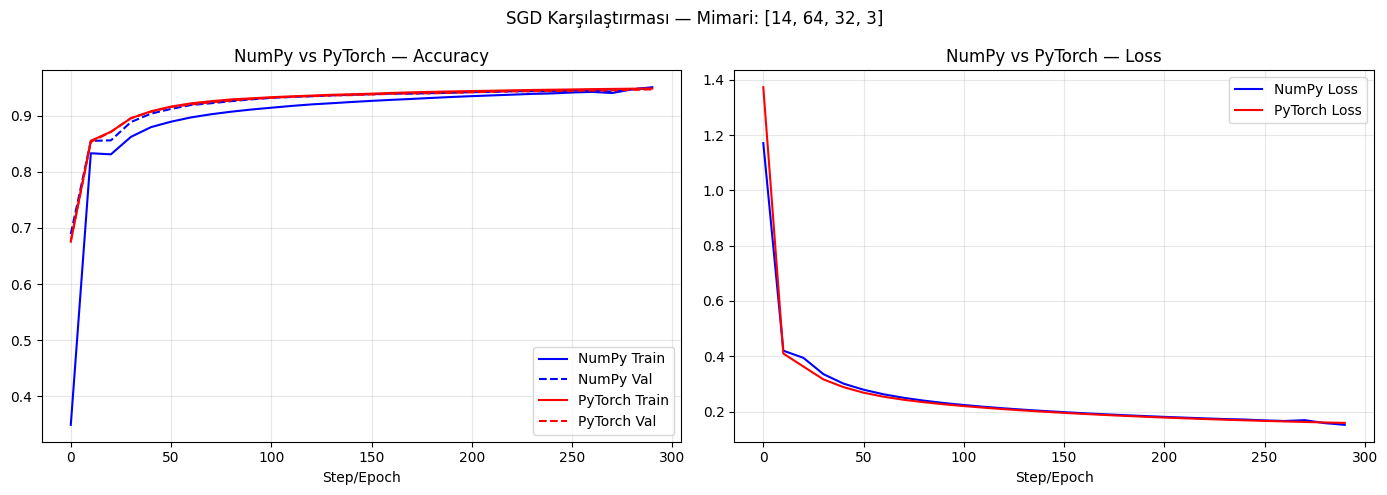

In [26]:
# Accuracy eğrisi karşılaştırması
s = list(range(0, N_STEPS, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(s, np_train_accs,  'b-',  label='NumPy Train')
ax1.plot(s, np_val_accs,    'b--', label='NumPy Val')
ax1.plot(s, pt_train_accs,  'r-',  label='PyTorch Train')
ax1.plot(s, pt_val_accs,    'r--', label='PyTorch Val')
ax1.set_title('NumPy vs PyTorch — Accuracy')
ax1.set_xlabel('Step/Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(s, np_costs,  'b-', label='NumPy Loss')
ax2.plot(s, pt_losses, 'r-', label='PyTorch Loss')
ax2.set_title('NumPy vs PyTorch — Loss')
ax2.set_xlabel('Step/Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'SGD Karşılaştırması — Mimari: {LAYERS}', fontsize=12)
plt.tight_layout(); plt.show()

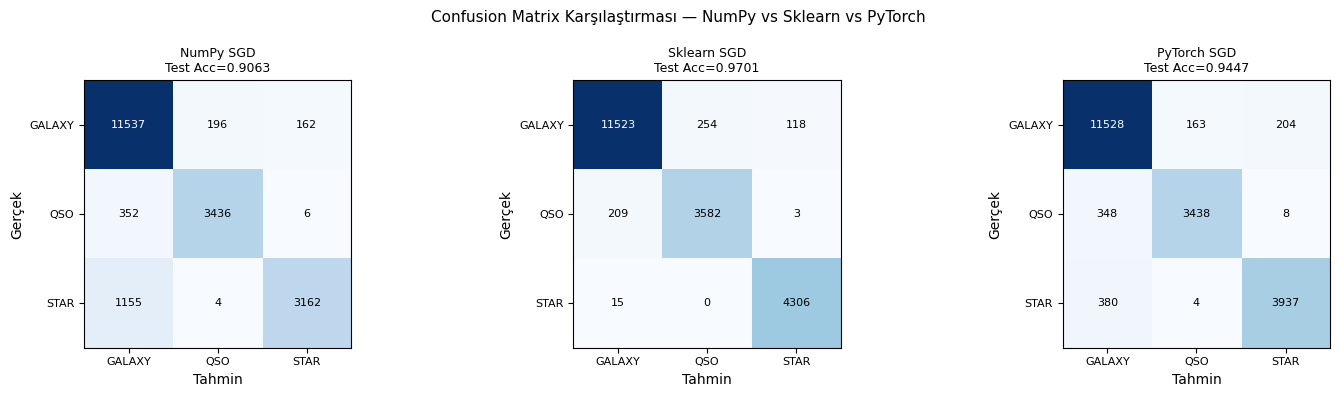

In [27]:
# Confusion Matrix — 3 yöntem yan yana
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_names = le.classes_

for ax, (name, pred) in zip(axes, [
    ('NumPy SGD',   y_pred_np),
    ('Sklearn SGD', y_pred_sk),
    ('PyTorch SGD', y_pred_pt)
]):
    cm = confusion_matrix(y_test_np, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(class_names, fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    acc = accuracy_score(y_test_np, pred)
    ax.set_title(f'{name}\nTest Acc={acc:.4f}', fontsize=9)
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=8,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle('Confusion Matrix Karşılaştırması — NumPy vs Sklearn vs PyTorch', fontsize=11)
plt.tight_layout(); plt.show()

In [28]:
# Classification Report — en iyi yöntem
accs = {'NumPy': (acc_np, y_pred_np), 'Sklearn': (acc_sk_test, y_pred_sk), 'PyTorch': (acc_pt, y_pred_pt)}
best_name = max(accs, key=lambda k: accs[k][0])
best_pred = accs[best_name][1]

print(f'En iyi yöntem: {best_name} (Test Acc={accs[best_name][0]:.4f})')
print()
print(classification_report(y_test_np, best_pred, target_names=le.classes_))

En iyi yöntem: Sklearn (Test Acc=0.9701)

              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.97     11895
         QSO       0.93      0.94      0.94      3794
        STAR       0.97      1.00      0.98      4321

    accuracy                           0.97     20010
   macro avg       0.96      0.97      0.97     20010
weighted avg       0.97      0.97      0.97     20010

